In [14]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
 
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
 
import torch
from datasets import DatasetDict, Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
import evaluate
import pickle
from datasets import load_from_disk
import optuna

warnings.filterwarnings("ignore")

In [15]:
encoded_dataset = load_from_disk("title_classifier_encoded_dataset_headlines_only.hf")  
# encoded_dataset.set_format("torch")

In [16]:
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)

mps


In [17]:
encoded_dataset.set_format("torch", device=device)

## Load the Encoder

In [18]:
import pickle
with open("/Users/philip.juachon/Desktop/Personal Learning/Deep Learning/final-project/artifacts/02_y_encoder.pkl", "rb") as f:
    y_encoder = pickle.load(f)

## Define Hyperparameter Tuning Helpers

In [19]:
def model_init():
    return AutoModelForSequenceClassification.from_pretrained(
        "distilbert-base-uncased", 
        num_labels=NUM_LABELS,
        id2label=id2label,
        label2id=label2id
    )

In [20]:
def optuna_hp_space(trial):
    return {
        # Explore learning rates between 1e-5 and 5e-5 (logarithmic scale)
        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True),
        # Test batch sizes of 16 vs 32
        "per_device_train_batch_size": trial.suggest_categorical("per_device_train_batch_size", [16, 32]),
        # Explore how much weight decay (regularization) helps
        "weight_decay": trial.suggest_float("weight_decay", 0.0, 0.1),
    }

## Sample the data

In [8]:
tune_train_data = encoded_dataset["train"].shuffle(seed=42).select(range(10000))
tune_eval_data = encoded_dataset["validation"].shuffle(seed=42).select(range(2000))

## Finetuning Proper

In [10]:
labels = y_encoder.classes_
id2label = {idx: label for idx, label in enumerate(labels)}
label2id = {label: idx for idx, label in enumerate(labels)}
NUM_LABELS = len(labels)

In [21]:
def compute_metrics(eval_pred):
    logits, true_labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    
    f1 = f1_score(true_labels, predictions, average='weighted')
    acc = accuracy_score(true_labels, predictions)
    return {"accuracy": acc, "f1": f1}

In [11]:
training_args = TrainingArguments(
    output_dir="./results_tuning_headlines_only",
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=2,              # Keep epochs low for the search phase!
    per_device_eval_batch_size=32,
    logging_steps=50,
    disable_tqdm=True,               # Turn off progress bars so it doesn't flood your screen
)

In [12]:
trainer = Trainer(
    model_init=model_init,           # Use the function, not the model!
    args=training_args,
    train_dataset=tune_train_data,   # Use the mini dataset!
    eval_dataset=tune_eval_data,
    compute_metrics=compute_metrics,
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [13]:
print("Starting Optuna Hyperparameter Search...")
best_trial = trainer.hyperparameter_search(
    direction="maximize",            # We want to MAXIMIZE the F1 score
    backend="optuna",
    hp_space=optuna_hp_space,
    n_trials=5                       # Try 5 different combinations
)

[I 2026-03-28 09:59:48,561] A new study created in memory with name: no-name-8a8ad661-b6ec-48bb-bd84-c2ce98378b43


Starting Optuna Hyperparameter Search...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '2.929', 'grad_norm': '4.147', 'learning_rate': '2.917e-05', 'epoch': '0.08'}
{'loss': '2.559', 'grad_norm': '5.762', 'learning_rate': '2.796e-05', 'epoch': '0.16'}
{'loss': '2.348', 'grad_norm': '6.208', 'learning_rate': '2.674e-05', 'epoch': '0.24'}
{'loss': '2.013', 'grad_norm': '7.243', 'learning_rate': '2.553e-05', 'epoch': '0.32'}
{'loss': '1.976', 'grad_norm': '8.385', 'learning_rate': '2.431e-05', 'epoch': '0.4'}
{'loss': '1.778', 'grad_norm': '8.876', 'learning_rate': '2.31e-05', 'epoch': '0.48'}
{'loss': '1.729', 'grad_norm': '8.785', 'learning_rate': '2.188e-05', 'epoch': '0.56'}
{'loss': '1.76', 'grad_norm': '14.1', 'learning_rate': '2.067e-05', 'epoch': '0.64'}
{'loss': '1.603', 'grad_norm': '7.525', 'learning_rate': '1.946e-05', 'epoch': '0.72'}
{'loss': '1.636', 'grad_norm': '8.072', 'learning_rate': '1.824e-05', 'epoch': '0.8'}
{'loss': '1.579', 'grad_norm': '14.27', 'learning_rate': '1.703e-05', 'epoch': '0.88'}
{'loss': '1.461', 'grad_norm': '11.89', 'learnin

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '1.371', 'grad_norm': '4.201', 'learning_rate': '2.182e-05', 'epoch': '1.118'}
{'loss': '1.189', 'grad_norm': '6.713', 'learning_rate': '1.788e-05', 'epoch': '1.278'}
{'loss': '1.175', 'grad_norm': '6.774', 'learning_rate': '1.394e-05', 'epoch': '1.438'}
{'loss': '1.094', 'grad_norm': '7.383', 'learning_rate': '1.001e-05', 'epoch': '1.597'}
{'loss': '1.152', 'grad_norm': '8.374', 'learning_rate': '6.066e-06', 'epoch': '1.757'}
{'loss': '1.126', 'grad_norm': '5.107', 'learning_rate': '2.127e-06', 'epoch': '1.917'}
{'eval_loss': '1.333', 'eval_accuracy': '0.639', 'eval_f1': '0.614', 'eval_runtime': '23.05', 'eval_samples_per_second': '86.77', 'eval_steps_per_second': '2.733', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '859.6', 'train_samples_per_second': '23.27', 'train_steps_per_second': '0.728', 'train_loss': '1.545', 'epoch': '2'}


[I 2026-03-28 11:14:05,305] Trial 4 finished with value: 1.2529870138360373 and parameters: {'learning_rate': 4.931685703283436e-05, 'per_device_train_batch_size': 32, 'weight_decay': 0.06092170230812595}. Best is trial 1 with value: 1.2632928874143976.


In [14]:
print("\n--- TUNING COMPLETE ---")
print(f"Best F1 Score Achieved: {best_trial.objective}")
print(f"Winning Hyperparameters: {best_trial.hyperparameters}")


--- TUNING COMPLETE ---
Best F1 Score Achieved: 1.2632928874143976
Winning Hyperparameters: {'learning_rate': 3.3634398899630135e-05, 'per_device_train_batch_size': 16, 'weight_decay': 0.0642706393348847}


## Fine tuning proper

In [22]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", 
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id
)

model = model.to(device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [23]:
WEIGHT_DECAY = 0.0642706393348847
SEED = 69
BATCH_SIZE = 16
EPOCHS = 5
LEARNING_RATE = 3.3634398899630135e-05
LOGGING_STEPS = 50

training_args = TrainingArguments(
    output_dir="/Users/philip.juachon/Desktop/Personal Learning/Deep Learning/final-project/output/results_base_model_headlines_only_tuned",
    learning_rate=LEARNING_RATE,              
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    num_train_epochs=EPOCHS,              
    weight_decay = WEIGHT_DECAY,
    seed = SEED,
    logging_steps = LOGGING_STEPS,
    eval_strategy="epoch",     
    save_strategy="epoch",           
    load_best_model_at_end=True,     
    metric_for_best_model="f1"
)

In [24]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["validation"],
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss


In [31]:
print("\nEvaluating on Test Set...")
print(trainer.evaluate(encoded_dataset["test"]))


Evaluating on Test Set...


{'eval_loss': 0.9022157788276672, 'eval_accuracy': 0.7609822646657571, 'eval_f1': 0.7600298640944934, 'eval_runtime': 473.0228, 'eval_samples_per_second': 85.228, 'eval_steps_per_second': 1.332, 'epoch': 5.0}


In [32]:
test_output = trainer.predict(encoded_dataset["test"])
predictions = np.argmax(test_output.predictions, axis=-1)
print(predictions)

[14 16  6 ... 12 16 22]


In [33]:
print(f"\n── Test set evaluation Headline + Short Description) ──")
test_output = trainer.predict(encoded_dataset["test"])
preds = np.argmax(test_output.predictions, axis=-1)


── Test set evaluation Headline + Short Description) ──


In [34]:
labels = test_output.label_ids

In [35]:
labels

array([14, 16,  6, ..., 12, 16, 22])

In [36]:
report = classification_report(
    labels, preds,
    target_names=y_encoder.classes_,
    digits=4,
    zero_division=0,
)
print(report)

                precision    recall  f1-score   support

ARTS & CULTURE     0.6115    0.6505    0.6304       784
  BLACK VOICES     0.5781    0.5371    0.5569       916
      BUSINESS     0.6170    0.6791    0.6466      1549
        COMEDY     0.6182    0.5482    0.5811      1078
         CRIME     0.6510    0.6428    0.6469       711
       DIVORCE     0.7866    0.8406    0.8127       684
 ENTERTAINMENT     0.7614    0.7921    0.7764      3472
   ENVIRONMENT     0.6050    0.6884    0.6440       812
  FOOD & DRINK     0.8503    0.8352    0.8427      1687
 HOME & LIVING     0.8209    0.8438    0.8322       858
        IMPACT     0.4825    0.4368    0.4585       696
         MEDIA     0.6530    0.5408    0.5916       588
     PARENTING     0.8106    0.7776    0.7938      2532
      POLITICS     0.8307    0.8457    0.8381      7117
  QUEER VOICES     0.7990    0.7738    0.7862      1269
      RELIGION     0.6518    0.5973    0.6234       514
SCIENCE & TECH     0.5773    0.6268    0.6010  

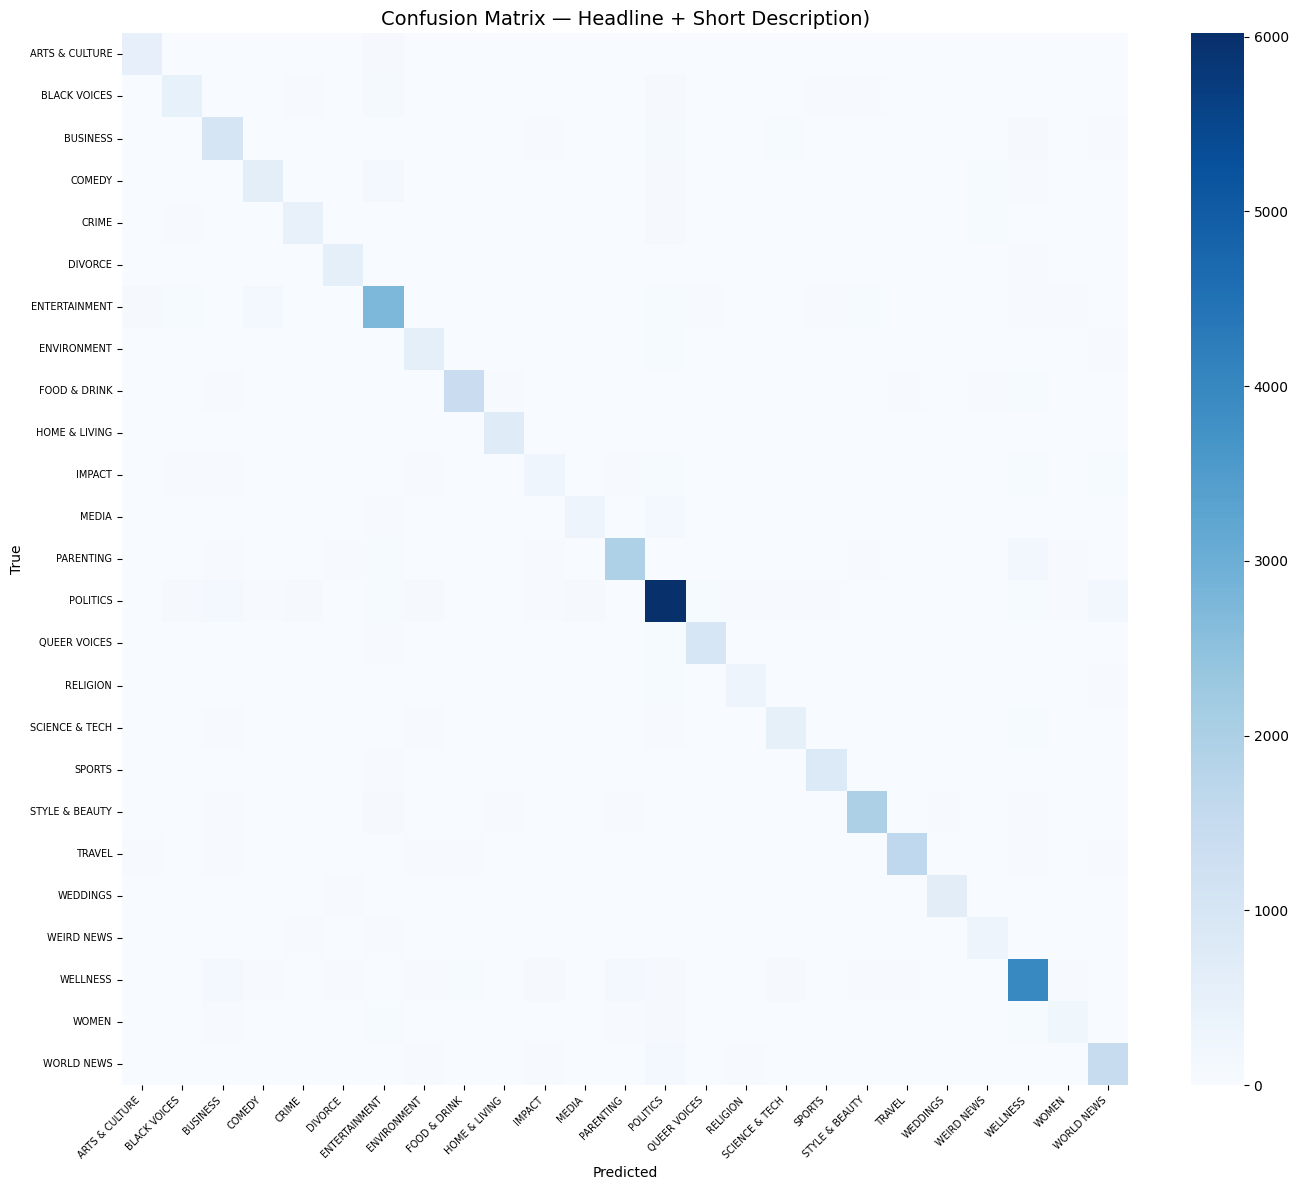

In [37]:
cm = confusion_matrix(labels, preds)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm, annot=False, fmt='d', cmap='Blues',
    xticklabels=y_encoder.classes_, yticklabels=y_encoder.classes_, ax=ax
)
ax.set_title(f"Confusion Matrix — Headline + Short Description)", fontsize=14)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()